In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

Reading dataset file.

In [2]:
houses = pd.read_csv('houses.csv', sep=None, engine='python');
houses.name = "Houses"

Printing number of records and attributes.

print(f"Number of records (rows): {houses.shape[0]}")
print(f"Number of attributes (columns): {houses.shape[1]}")

Attributes:
median_house_value – median value of houses in the area.
median_income – median income of households in the area.
housing_median_age – median age of houses in the area.
total_rooms – total number of rooms in all houses within the area.
total_bedrooms – total number of bedrooms in all houses within the area.
population – total number of people living in the area.
households – total number of households.
latitude – north–south geographical coordinate of the area.
longitude – east–west geographical coordinate of the area.

In [3]:
print(f"Attributs: {houses.columns.tolist()}")

Attributs: ['median_house_value', 'median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'latitude', 'longitude']


Data example:

In [4]:
houses.head(5)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.2574,52.0,1467.0,190.0,496.0,177.0,37.85,-122.24
3,341300.0,5.6431,52.0,1274.0,235.0,558.0,219.0,37.85,-122.25
4,342200.0,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25


Dataset has 0 duplicated records. That's great.

In [5]:
houses.duplicated().sum()

np.int64(0)

Dataset has 0 missing values. That's also great.

In [6]:
houses.isna().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

Cleaning outliers.

In [7]:
houses_cleaned = houses.copy()

for atr in houses_cleaned.columns:
    # IQR border
    Q1 = houses_cleaned[atr].quantile(0.25)
    Q3 = houses_cleaned[atr].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR

    # Deleting IQR outliers
    houses_cleaned = houses_cleaned[
        (houses_cleaned[atr] >= lower_iqr) &
        (houses_cleaned[atr] <= upper_iqr)
    ]

print(f"Cleaned {houses.shape[0] - houses_cleaned.shape[0]} rows.")

Cleaned 3717 rows.


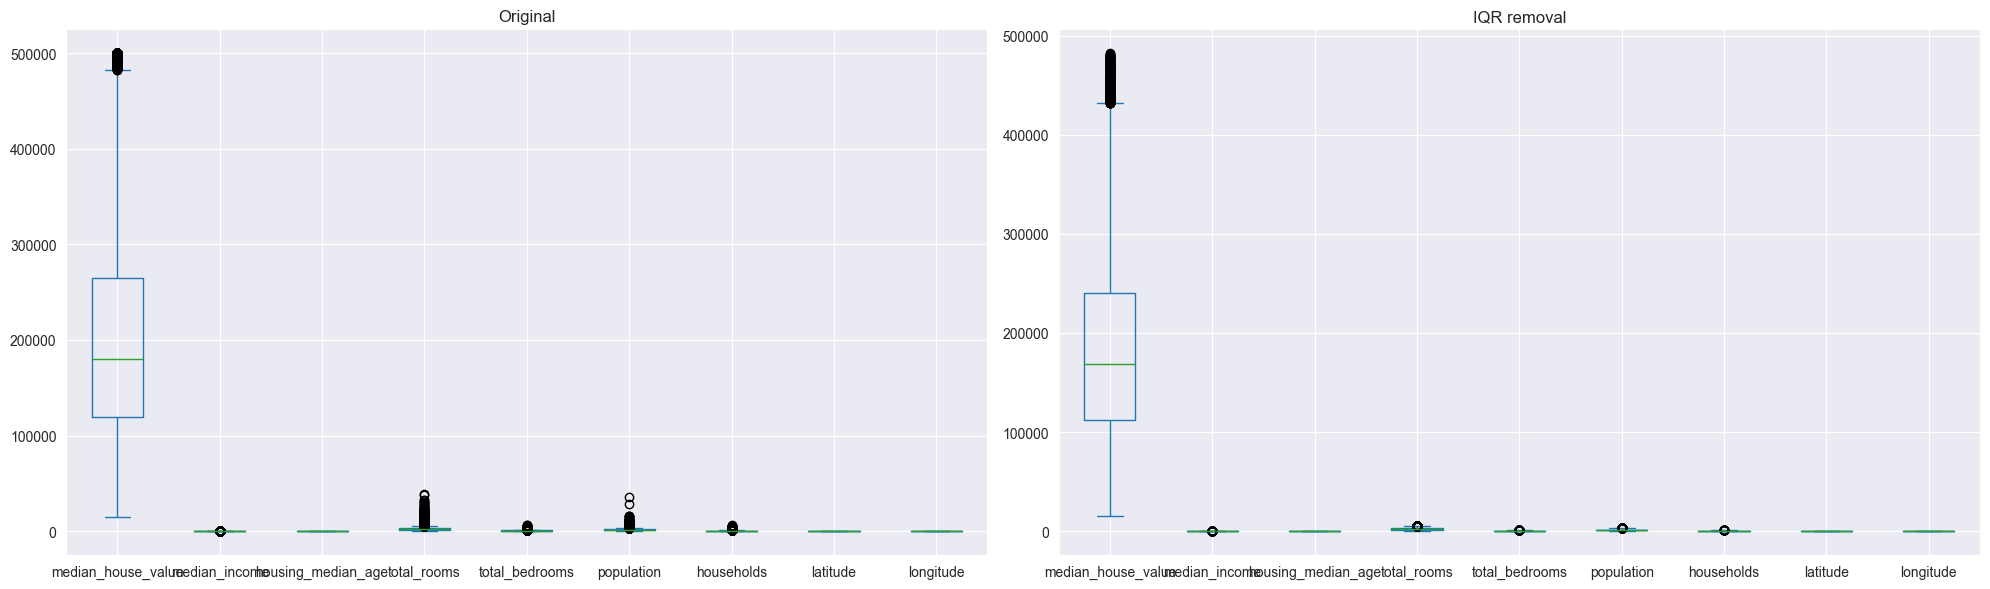

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
houses.plot.box(ax=axes[0], title="Original")
houses_cleaned.plot.box(ax=axes[1], title="IQR removal")
plt.tight_layout()
plt.show()

Printing Mean, median, min, max, std values of attributes after cleaning.

In [9]:
pd.options.display.float_format = "{:.1f}".format
houses_cleaned.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0
mean,185595.5,3.6,29.7,2075.4,428.7,1153.6,401.1,35.7,-119.6
std,93016.0,1.4,12.2,1026.1,202.1,553.7,187.4,2.2,2.0
min,14999.0,0.5,1.0,2.0,2.0,3.0,2.0,32.5,-124.3
25%,112500.0,2.5,20.0,1348.0,282.0,755.0,268.0,33.9,-121.8
50%,168800.0,3.4,30.0,1934.0,403.0,1088.0,380.0,34.4,-118.7
75%,240200.0,4.5,38.0,2692.0,557.0,1509.0,522.0,37.8,-118.0
max,482200.0,7.6,52.0,5600.0,1056.0,2762.0,916.0,42.0,-114.5


Attributes distribution: The difference interval for all attributes look valid.

array([[<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>]], dtype=object)

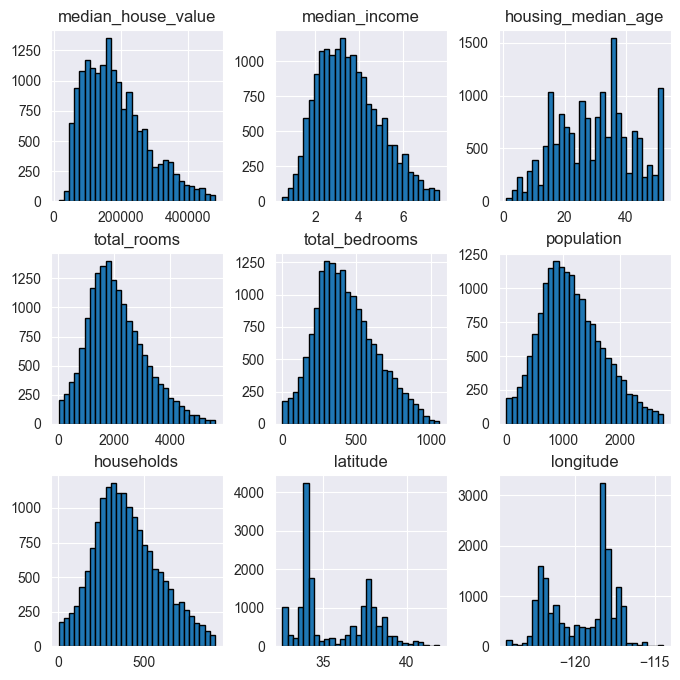

In [10]:
houses_cleaned.hist(figsize=(8, 8), bins=30, edgecolor='black')

None of the features have a strictly normal distribution. 'median_house_value', 'median_income', 'total_rooms', 'total_bedrooms', 'population', and 'households' have right-skewed distributions (skew > 0). 'housing_median_age' has a distribution similar to uniform. 'latitude' and 'longitude' are multi-peaked features, truncated by geography, clearly not normal.

In [11]:
houses_cleaned.skew()

median_house_value    0.8
median_income         0.5
housing_median_age   -0.0
total_rooms           0.6
total_bedrooms        0.5
population            0.5
households            0.4
latitude              0.4
longitude            -0.3
dtype: float64

Preliminary correlation analysis:
The main correlation that can be worked with is the correlation between attributes 'median_house_value' and 'median_income'. The remaining strong correlations are of no use because it is quite logical why they are so interrelated. If the value of 'total_bedrooms' increases, it is logical that the value of 'total_rooms' will also increase. The values of 'population' and 'households' will also increase because the more rooms there are, the more people can live in them, and more households will need to be built for these rooms.

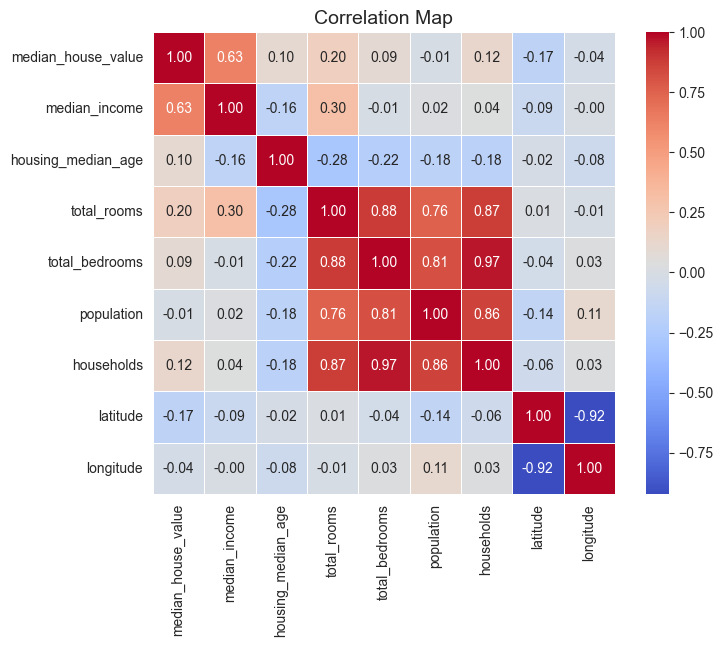

In [12]:
# Computing the correlation matrix
corr_tab = houses_cleaned.corr(numeric_only=True)

# Plotting the map
plt.figure(figsize=(8, 6))
sns.heatmap(corr_tab, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Map", fontsize=14)
plt.show()

Plotting graph of the relationship between 'median_house_value' and 'median_income'.

<Axes: xlabel='median_house_value', ylabel='median_income'>

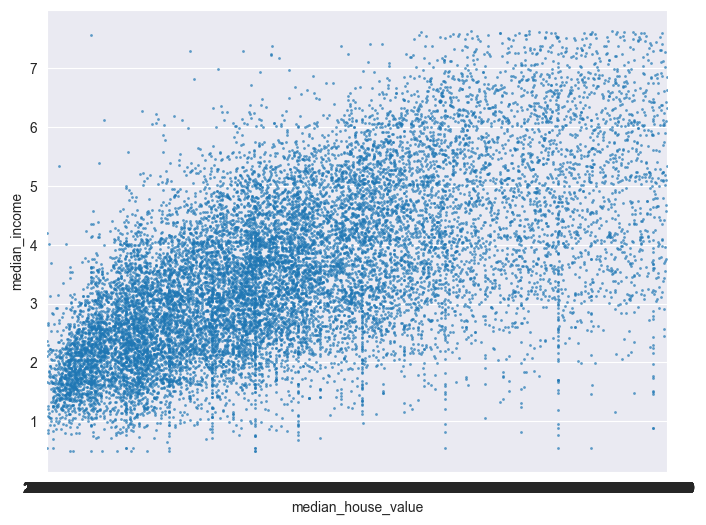

In [13]:
plt.figure(figsize=(8, 6))
sns.stripplot(data=houses_cleaned, x='median_house_value', y='median_income', jitter=True, size=2, alpha=0.7)

Splitting dataset into features and target variable.

In [14]:
X_raw = houses_cleaned.drop(columns='median_house_value')
y_raw = houses_cleaned['median_house_value']

Splitting dataset into 2 parts: training(85%), and test(15%).

In [15]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.15, random_state=4)

Data normalization: for ‘median_house_value’, ‘median_income’, ‘total_rooms’, ‘total_bedrooms’, ‘population’, ‘households’, and target value 'median_house_value' in train dataset we use logarithmic transformation because all values have right-skewed asymmetry, with a long tail to the right and a distribution that is not normal but closer to log-normal. Then, for all attributes, we perform robust scaling because of different scales and non-normal distribution.
We leave ‘latitude’ and ‘longitude’ untouched because they are geographical features and if we transform them, they will lose their informativeness.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

X_scaler = Pipeline([
    ('log_transform', ColumnTransformer([('log', FunctionTransformer(np.log1p, validate=False), [0, 1, 2, 3, 4, 5])], remainder='passthrough')),
    ('robust_scaling', ColumnTransformer([('robust', RobustScaler(), [0, 1, 2, 3, 4, 5])], remainder='passthrough',  verbose_feature_names_out=False))
])

y_scaler = Pipeline([('log', FunctionTransformer(np.log1p, validate=False)), ('robust', RobustScaler())])

X_train_trf = X_scaler.fit_transform(X_train_raw)

y_train_raw_2d = y_train_raw.to_frame()
y_train_trf = y_scaler.fit_transform(y_train_raw_2d)

X_train = pd.DataFrame(X_train_trf, columns=X_raw.columns)
y_train = pd.DataFrame(y_train_trf, columns=['median_house_value'])

Plotting histograms of normalized data.

array([[<Axes: title={'center': 'median_house_value'}>]], dtype=object)

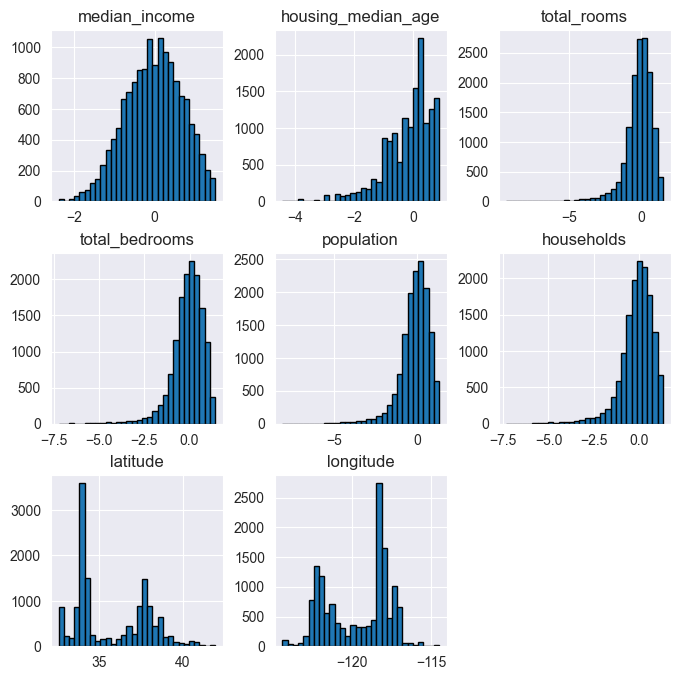

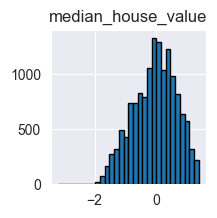

In [17]:
X_train.hist(figsize=(8, 8), bins=30, edgecolor='black')
y_train.hist(figsize=(2, 2), bins=30, edgecolor='black')

Making basic Multi-layer Perceptron Regressor model with one hidden layer, which has 16 neurons and relu activation cause its most useful for most situations. For fitting using Adam optimizer.

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model0 = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1)
])

model0.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training our model.

In [38]:
history0 = model0.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=2
)

Epoch 1/20
360/360 - 1s - 3ms/step - loss: 126.5504 - mae: 5.2150 - val_loss: 0.8256 - val_mae: 0.7503
Epoch 2/20
360/360 - 0s - 961us/step - loss: 0.6985 - mae: 0.6912 - val_loss: 0.6047 - val_mae: 0.6369
Epoch 3/20
360/360 - 0s - 924us/step - loss: 0.5464 - mae: 0.6049 - val_loss: 0.4978 - val_mae: 0.5657
Epoch 4/20
360/360 - 0s - 1ms/step - loss: 0.4720 - mae: 0.5532 - val_loss: 0.4497 - val_mae: 0.5427
Epoch 5/20
360/360 - 0s - 1ms/step - loss: 0.4326 - mae: 0.5243 - val_loss: 0.4160 - val_mae: 0.5137
Epoch 6/20
360/360 - 0s - 974us/step - loss: 0.4041 - mae: 0.5033 - val_loss: 0.3893 - val_mae: 0.4954
Epoch 7/20
360/360 - 0s - 926us/step - loss: 0.3596 - mae: 0.4706 - val_loss: 0.2741 - val_mae: 0.4030
Epoch 8/20
360/360 - 0s - 918us/step - loss: 0.2453 - mae: 0.3832 - val_loss: 0.2385 - val_mae: 0.3748
Epoch 9/20
360/360 - 0s - 878us/step - loss: 0.2251 - mae: 0.3655 - val_loss: 0.2356 - val_mae: 0.3697
Epoch 10/20
360/360 - 0s - 902us/step - loss: 0.2204 - mae: 0.3611 - val_loss

Defining a function to plot training and validation loss.

In [39]:
def plot_loss(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(6,3))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.ylim(0, 2)
    plt.legend()
    plt.show()

We can see that after the 10th epoch, the model gets stuck at value around 0.25 and cannot continue to reduce loss. This means that the model needs to be made more complex in order to find more complex dependencies in the data.

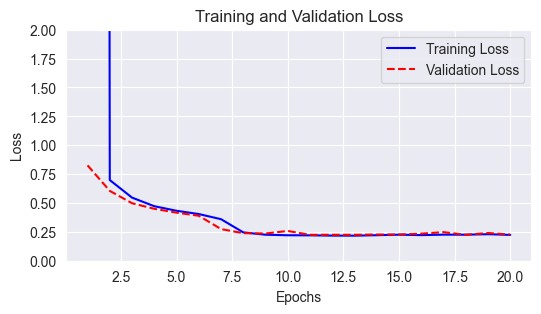

In [40]:
plot_loss(history0)

Defining a function to evaluate the model on the test set. Function calculates Mean Squared Error and Estimated Accuracy in percents. To obtain the Estimated Accuracy value, we first calculate MAPE (mean absolute percentage error). To do this, for each example, we take the modulus of the difference between the predicted and true values, and to understand how large the error is relative to the value itself, we divide it by the true value. Then we average all the data by dividing it by its number and multiply it by 100 to express it as a percentage. The MAPE indicator shows the average percentage difference between predictions and actual values. Estimated accuracy percent is equal to 100 minus MAPE and shows how close the predictions are to the true data in percentage terms.

In [22]:
def evaluate_model(model, x, y):
    # Transform test data
    X_test_trf = X_scaler.transform(x)
    X_test = pd.DataFrame(X_test_trf, columns=x.columns)

    y_test_raw_2d  = y.to_frame()
    y_test_trf = y_scaler.transform(y_test_raw_2d)

    # Predict and inverse transform
    y_pred_scaled = model.predict(X_test)
    y_pred = np.expm1(y_scaler.named_steps['log'].inverse_transform(y_scaler.named_steps['robust'].inverse_transform(y_pred_scaled)))
    y_true = np.expm1(y_scaler.named_steps['log'].inverse_transform(y_scaler.named_steps['robust'].inverse_transform(y_test_trf)))

    # Mean absolute error
    mae = np.mean(np.abs(y_true - y_pred))

    # Avoiding division by zero
    y_true0 = np.where(y_true == 0, 1e-8, y_true)

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true0)) * 100.0
    accuracy_percent = max(0.0, 100.0 - mape)

    print(f"Test Loss (MAE): {mae:.4f}")
    print(f"Estimated Accuracy: {accuracy_percent:.2f}%")

    return

Mean Absolute Error is around 45000, and estimated accuracy is around 70% which is good for first try, but we can make it even better. We need to improve our model.

In [41]:
evaluate_model(model0, X_test_raw, y_test_raw)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step
Test Loss (MAE): 46782.6954
Estimated Accuracy: 71.36%


In [24]:
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245 (984.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 164 (660.00 B)

### Improving our model:

Adding more layers and neurons in them. Adding batch normalization which normalizes neuron activations in each batch, making training more stable, faster, and resistant to overfitting. And also adding early stopping, for stopping training our model if validation loss stops decreasing for 10 epochs, which also saves the best parameter values throughout the entire selection process.

In [55]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization

model1 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),

    Dense(32, activation="relu"),
    BatchNormalization(),

    Dense(16, activation="relu"),

    Dense(1)
])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model1.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

history1 = model1.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/100


C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


360/360 - 1s - 4ms/step - loss: 0.2440 - mae: 0.3689 - val_loss: 1.9533 - val_mae: 1.2636
Epoch 2/100
360/360 - 0s - 1ms/step - loss: 0.1639 - mae: 0.3086 - val_loss: 1.8826 - val_mae: 1.2401
Epoch 3/100
360/360 - 0s - 1ms/step - loss: 0.1497 - mae: 0.2926 - val_loss: 4.6673 - val_mae: 2.0339
Epoch 4/100
360/360 - 0s - 1ms/step - loss: 0.1421 - mae: 0.2822 - val_loss: 1.2785 - val_mae: 0.9876
Epoch 5/100
360/360 - 0s - 1ms/step - loss: 0.1359 - mae: 0.2760 - val_loss: 0.3582 - val_mae: 0.4991
Epoch 6/100
360/360 - 0s - 1ms/step - loss: 0.1388 - mae: 0.2798 - val_loss: 0.2590 - val_mae: 0.3837
Epoch 7/100
360/360 - 0s - 1ms/step - loss: 0.1355 - mae: 0.2751 - val_loss: 0.2488 - val_mae: 0.4002
Epoch 8/100
360/360 - 0s - 1ms/step - loss: 0.1305 - mae: 0.2717 - val_loss: 0.2358 - val_mae: 0.3733
Epoch 9/100
360/360 - 0s - 1ms/step - loss: 0.1278 - mae: 0.2681 - val_loss: 0.9082 - val_mae: 0.8392
Epoch 10/100
360/360 - 0s - 1ms/step - loss: 0.1287 - mae: 0.2681 - val_loss: 0.6073 - val_mae

Now we can see that the training loss has decreased, but the validation loss has fluctuated and eventually stopped decreasing. These are signs of overfitting, which needs to be fixed.

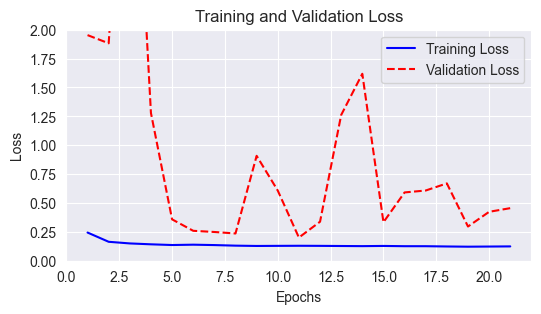

In [56]:
plot_loss(history1)

Results became a little better. Now the Estimated Accuracy is 75%.

In [57]:
evaluate_model(model1, X_test_raw, y_test_raw)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Loss (MAE): 45631.8895
Estimated Accuracy: 75.30%


Adding kernel regularizer.

In [154]:
from tensorflow.keras.regularizers import l2

model2 = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation="relu"),
    Dropout(0.2),

    Dense(1)
])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model2.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

history2 = model2.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/100


C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


338/338 - 2s - 5ms/step - loss: 0.5046 - mae: 0.5263 - val_loss: 1.5749 - val_mae: 1.0994
Epoch 2/100
338/338 - 1s - 2ms/step - loss: 0.3010 - mae: 0.4052 - val_loss: 0.5330 - val_mae: 0.5855
Epoch 3/100
338/338 - 1s - 2ms/step - loss: 0.2631 - mae: 0.3710 - val_loss: 0.8970 - val_mae: 0.8160
Epoch 4/100
338/338 - 1s - 1ms/step - loss: 0.2451 - mae: 0.3593 - val_loss: 0.5436 - val_mae: 0.5872
Epoch 5/100
338/338 - 1s - 2ms/step - loss: 0.2374 - mae: 0.3528 - val_loss: 0.2559 - val_mae: 0.3761
Epoch 6/100
338/338 - 0s - 1ms/step - loss: 0.2279 - mae: 0.3476 - val_loss: 1.7432 - val_mae: 1.2384
Epoch 7/100
338/338 - 1s - 1ms/step - loss: 0.2181 - mae: 0.3397 - val_loss: 0.7878 - val_mae: 0.7767
Epoch 8/100
338/338 - 0s - 1ms/step - loss: 0.2165 - mae: 0.3385 - val_loss: 0.2690 - val_mae: 0.4023
Epoch 9/100
338/338 - 0s - 1ms/step - loss: 0.2080 - mae: 0.3344 - val_loss: 0.3258 - val_mae: 0.4313
Epoch 10/100
338/338 - 0s - 1ms/step - loss: 0.2097 - mae: 0.3356 - val_loss: 0.3232 - val_mae

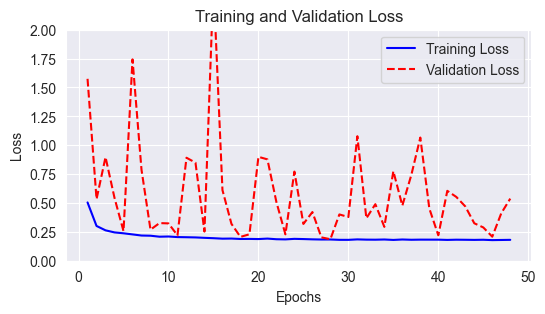

In [155]:
plot_loss(history2)

In [156]:
evaluate_model(model2, X_test_raw, y_test_raw)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Test Loss (MAE): 43491.2471
Estimated Accuracy: 74.24%
